In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Dataset columns and definition:

1. credit.policy: 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.

2. purpose: The purpose of the loan (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").

3. int.rate: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11). Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.

4. installment: The monthly installments owed by the borrower if the loan is funded.

5. log.annual.inc: The natural log of the self-reported annual income of the borrower.

6. dti: The debt-to-income ratio of the borrower (amount of debt divided by annual income).

7. fico: The FICO credit score of the borrower.

8. days.with.cr.line: The number of days the borrower has had a credit line.

9. revol.bal: The borrower's revolving balance (amount unpaid at the end of the credit card billing cycle).

10. revol.util: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).

11. inq.last.6mths: The borrower's number of inquiries by creditors in the last 6 months.

12. delinq.2yrs: The number of times the borrower had been 30+ days past due on a payment in the past 2 years.

13. pub.rec: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).

14. not.fully.paid: The customer of who fully paid the loan or not.

In [ ]:
df = pd.read_csv(r"D:\Python\ML\30_DAYS_ML_DL\Project_1\data\raw\loan_data.xls")
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB


In [6]:
df.shape

(9578, 14)

In [9]:
df.head(5)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [10]:
df.tail(5)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,debt_consolidation,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


In [11]:
df.sample(5)

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
5968,1,small_business,0.1774,612.36,11.079061,14.13,687,5749.000000,20429,66.1,2,0,0,1
1158,1,major_purchase,0.1134,230.30,10.463103,5.69,682,5249.958333,2745,40.4,0,0,0,0
2664,1,all_other,0.0800,313.37,11.350359,1.06,772,6780.000000,2227,5.4,0,0,0,0
8513,0,debt_consolidation,0.1482,414.93,10.545341,9.76,652,2609.958333,5628,54.6,0,0,0,0
8654,0,debt_consolidation,0.0945,160.05,10.596635,10.53,722,3240.000000,17755,30.7,4,0,0,0


#### Data Cleaning

In [7]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [13]:
for i in df.columns:
    print(i, ':', df[i].unique(), '\n')

credit.policy : [1 0] 

purpose : <StringArray>
['debt_consolidation',        'credit_card',          'all_other',
   'home_improvement',     'small_business',     'major_purchase',
        'educational']
Length: 7, dtype: str 

int.rate : [0.1189 0.1071 0.1357 0.1008 0.1426 0.0788 0.1496 0.1114 0.1134 0.1221
 0.1347 0.1324 0.0859 0.0714 0.0863 0.1103 0.1317 0.0894 0.1039 0.1513
 0.08   0.1355 0.1229 0.0901 0.0743 0.1375 0.0807 0.1028 0.087  0.1122
 0.0996 0.0933 0.0838 0.0775 0.1059 0.1596 0.1154 0.1343 0.1249 0.0964
 0.1186 0.1501 0.128  0.1091 0.1217 0.1533 0.0712 0.1438 0.1565 0.1467
 0.1312 0.147  0.1407 0.1014 0.1046 0.133  0.0983 0.1393 0.092  0.1236
 0.1362 0.1078 0.1583 0.1109 0.1141 0.1267 0.1204 0.0951 0.1172 0.1299
 0.1488 0.152  0.1425 0.1836 0.1615 0.06   0.0832 0.1261 0.0945 0.1197
 0.1387 0.0976 0.1292 0.0737 0.0768 0.1166 0.1418 0.1545 0.1482 0.1703
 0.145  0.1671 0.1576 0.1608 0.164  0.1734 0.1051 0.157  0.1222 0.1273
 0.1379 0.1253 0.1128 0.1286 0.1287 0.097  0.1001 

In [14]:
df['not.fully.paid'].value_counts()

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

In [33]:
num_cols = df.select_dtypes(exclude='str').columns
cat_cols = df.select_dtypes(include='str').columns

#### Visualiztions

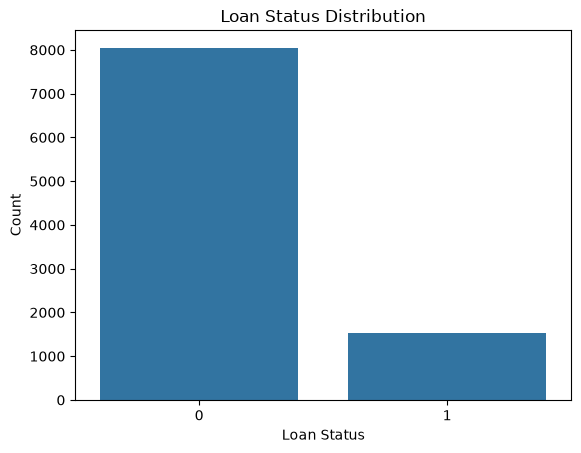

In [25]:
plt.Figure(figsize=(8,6))
sns.countplot(data=df, x='not.fully.paid')
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Loan Status Distribution")
plt.show()

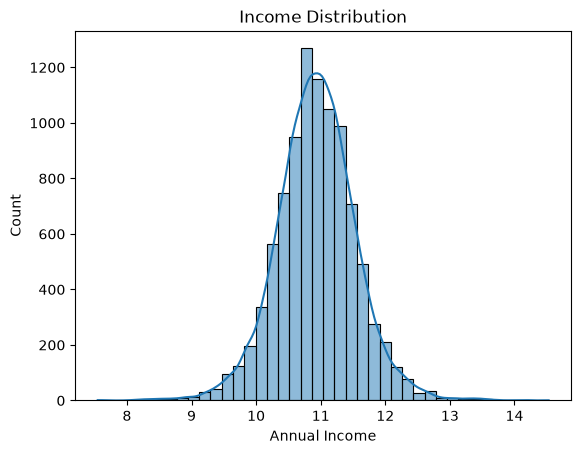

In [24]:
sns.histplot(df['log.annual.inc'], bins=40, kde=True)
plt.xlabel("Annual Income")
plt.ylabel("Count")
plt.title("Income Distribution")
plt.show()

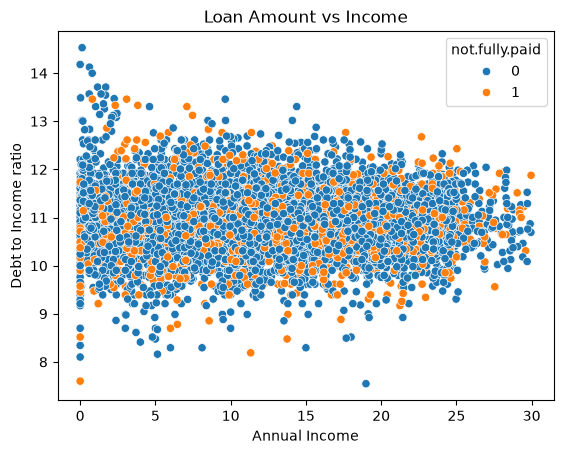

In [29]:
sns.scatterplot(x=df['dti'], y=df['log.annual.inc'], hue=df['not.fully.paid'])
plt.xlabel("Annual Income")
plt.ylabel("Debt to Income ratio")
plt.title("Loan Amount vs Income")
plt.show()

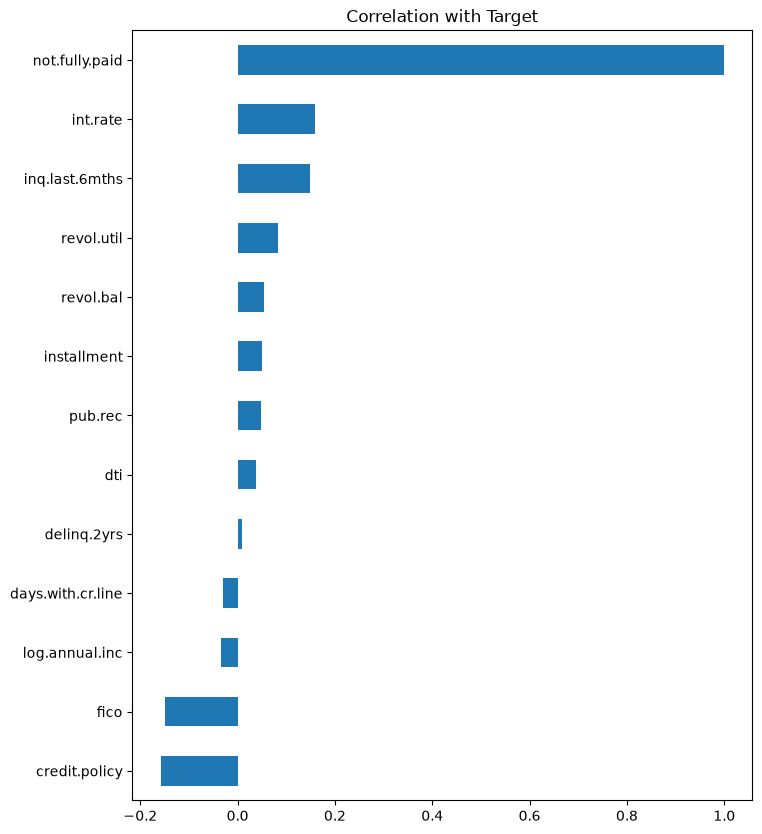

In [41]:
corr = df[num_cols].corr()['not.fully.paid'].sort_values()
plt.figure(figsize=(8,10))
corr.plot(kind='barh')
plt.title("Correlation with Target")
plt.show()

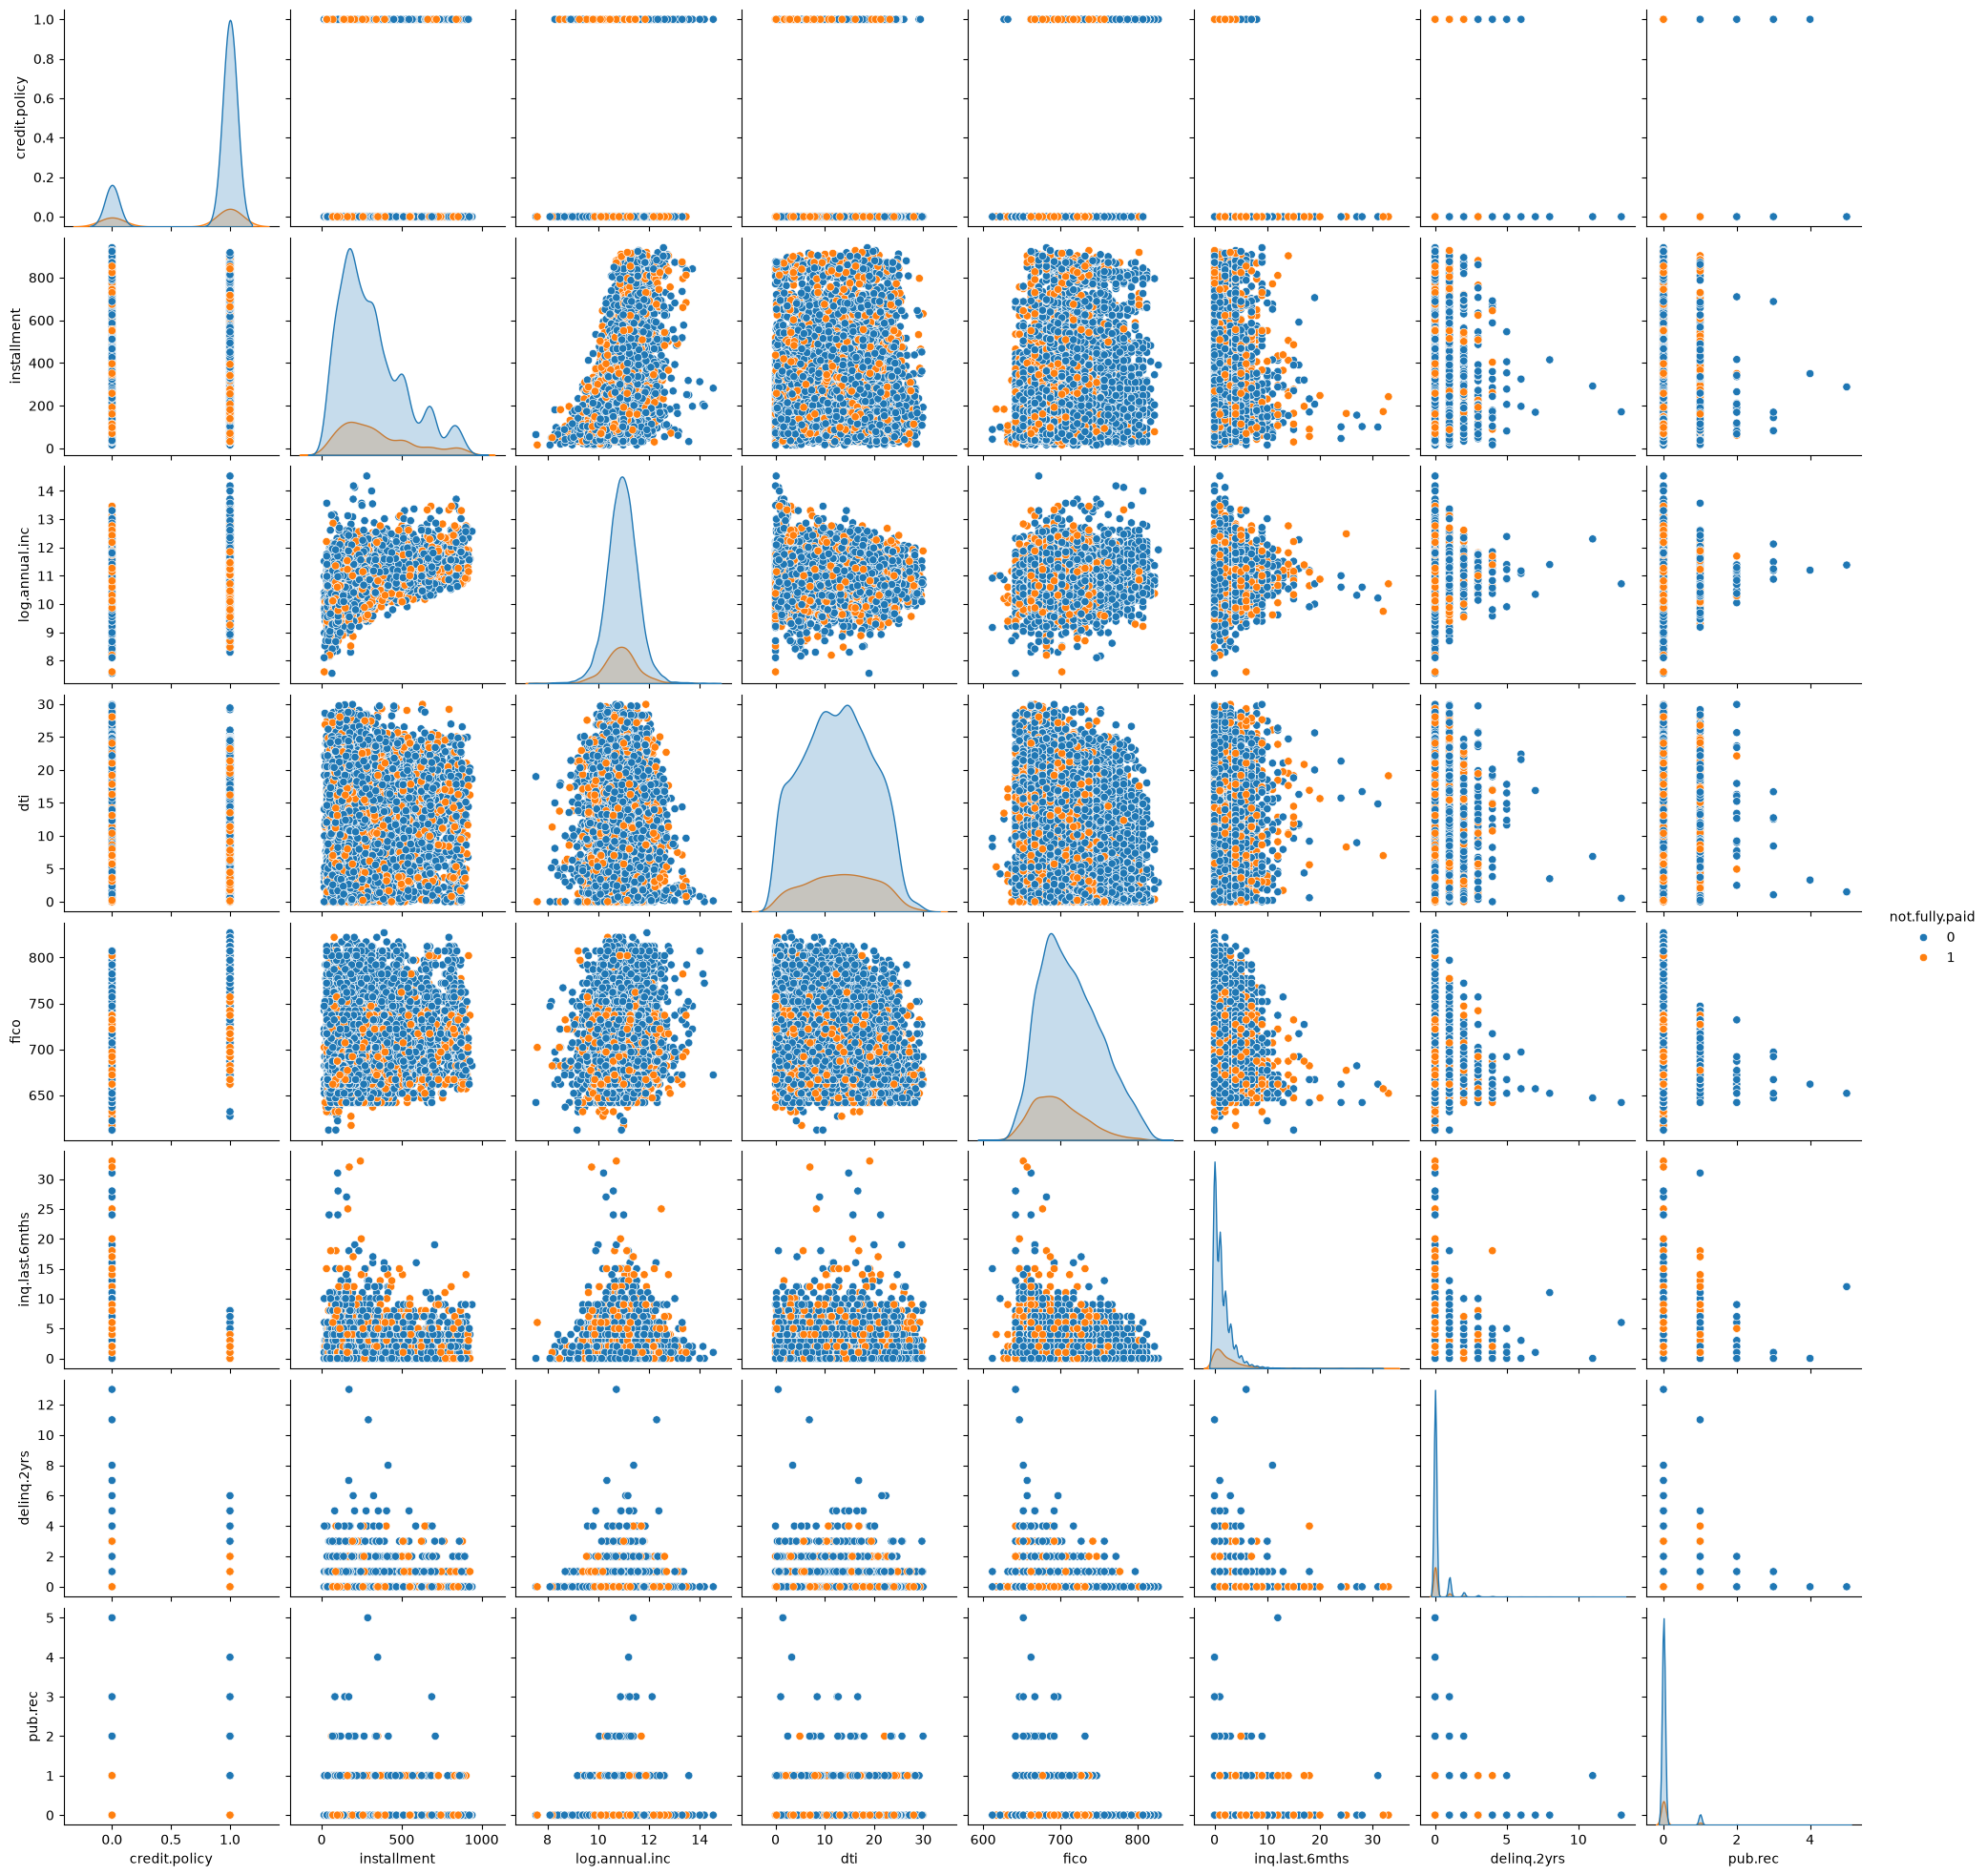

In [53]:
# sns.pairplot(df[num_cols], hue='not.fully.paid')

cols = ['credit.policy', 'installment', 'log.annual.inc', 'dti', 'fico', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']
sns.pairplot(df[cols], hue='not.fully.paid')
plt.show()